# Анализ данных и подготовка признаков

Ноутбук покрывает три задачи:
- первичный анализ Excel-датасета;
- первый ML-пайплайн по табличным признакам;
- улучшенную временную оценку через лаги и `walk-forward validation`.

Логика временного разбиения:
- `train`: все годы, кроме двух последних;
- `validation`: предпоследний год;
- `test`: последний год.

Для более честной проверки ниже также добавлен `walk-forward`, где модель много раз обучается на прошлом и предсказывает следующий год.


In [ ]:
%pip install pandas openpyxl matplotlib seaborn scipy scikit-learn

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import TransformedTargetRegressor
from sklearn.ensemble import AdaBoostRegressor, ExtraTreesRegressor, GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 180)
sns.set_theme(style='whitegrid', font_scale=0.9)

In [2]:
DATA_PATH = Path('../data/Datasety-1_cleaned.xlsx')

if not DATA_PATH.exists():
    raise FileNotFoundError(f'Файл не найден: {DATA_PATH.resolve()}')

DATA_PATH.resolve()

PosixPath('/Users/an.kornn/PycharmProjects/Diplom_Depart/data/Datasety-1_cleaned.xlsx')

In [3]:
excel_file = pd.ExcelFile(DATA_PATH)
sheet_names = excel_file.sheet_names
sheet_names

['Sheet1']

In [4]:
def try_convert_numeric(series: pd.Series) -> pd.Series:
    if pd.api.types.is_numeric_dtype(series):
        return series

    cleaned = (
        series.astype(str)
        .str.replace('\u00A0', '', regex=False)
        .str.replace(' ', '', regex=False)
        .str.replace(',', '.', regex=False)
        .replace({'nan': np.nan, 'None': np.nan, '': np.nan})
    )

    converted = pd.to_numeric(cleaned, errors='coerce')
    original_non_null = series.notna().sum()
    converted_non_null = converted.notna().sum()

    if original_non_null > 0 and converted_non_null / original_non_null >= 0.8:
        return converted
    return series


def normalize_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    normalized = df.copy()
    for col in normalized.columns:
        normalized[col] = try_convert_numeric(normalized[col])
    return normalized


In [5]:
raw_sheets = {sheet: pd.read_excel(DATA_PATH, sheet_name=sheet) for sheet in sheet_names}
prepared_sheets = {sheet: normalize_dataframe(df) for sheet, df in raw_sheets.items()}

for sheet, df in prepared_sheets.items():
    print('=' * 100)
    print(f'Лист: {sheet}')
    print(f'Размер: {df.shape[0]} строк x {df.shape[1]} столбцов')
    display(df.head())


Лист: Sheet1
Размер: 26 строк x 26 столбцов


,Год,Объем инвестиций в основной капитал,Валовый региональный продукт,Валовой региональный продукт на душу населения,Оборот розничной торговли,Среднедушевые денежные доходы населения в год,Реальные денежные доходы,Численность населения Тюменской области,Население моложе трудоспособного возраста,Население в трудоспособном возрасте,Коэффициенты демографической нагрузки,Среднемесячная номинальная начисленная заработная плата работников организаций,Потребительские расходы в среднем на душу населения,Индекс физического объема валового регионального продукта,"Задолженность по кредитам в рублях, предоставленным кредитными организациями физическим лицам","Стоимость основных фондов по Тюм обл, на конец года, по полной учетной стоимости",Ввод в действие основных фондов,Число организаций,Сальдированный финансовый результат (прибыль минус убыток) деятельности организаций,Удельный вес убыточных организаций,Индексы потребительских цен,Внешняя торговля со странами дальнего зарубежья: Экспорт,Внешняя торговля со странами дальнего зарубежья: Импорт,Внешний долг Российской Федерации по состоянию на конец отчетного года,Среднегодовая цена на нефть марки Brent на спотовом рынке,Курс доллара среднегодовой
0,1998,4738.0,188611.3,58587.7,1042799.4,2129.0,79.2,3212536,25.1,63.9,545,2792.9,1270.2,97.3,1396.89,903930,47050,63831,32246,56.7,164.5,6197.8,888.3,188534.0,12.72,9.7051
1,1999,5995.2,316194.7,98130.1,1797390.0,3266.0,88.5,3226093,24.2,64.7,523,4054.8,1879.9,101.9,1462.86,782654,51746,65973,113148,44.3,136.3,8445.3,481.8,178256.0,17.97,24.6199
2,2000,10434.3,570790.2,176917.9,2352274.3,4935.0,124.3,3218356,23.1,66.3,508,6706.8,2144.0,109.4,1570.60,1350459,103378,69319,223243,39.4,120.8,14623.5,707.3,160234.0,28.50,28.1292
3,2001,13849.5,753119.2,232236.3,3070014.0,7109.0,118.7,3234252,22.4,67.0,493,9980.0,2954.0,110.4,1571.00,2575384,174764,73598,215217,34.5,119.9,13926.2,766.7,146553.0,24.44,29.1685
4,2002,17209.9,898722.4,275622.5,3765363.6,8559.0,102.4,3264841,21.6,67.8,475,12083.3,3870.0,104.9,3952.10,3416427,256363,78202,186689,43.2,115.5,17461.4,566.4,151302.0,25.02,31.3419


## Проверка типов данных

In [6]:
dtype_reports = {}

for sheet, df in prepared_sheets.items():
    report = pd.DataFrame({
        'column': df.columns,
        'dtype': df.dtypes.astype(str).values,
        'is_numeric': [pd.api.types.is_numeric_dtype(df[col]) for col in df.columns],
        'non_null_count': [df[col].notna().sum() for col in df.columns],
        'null_count': [df[col].isna().sum() for col in df.columns],
    })
    dtype_reports[sheet] = report

    print('=' * 100)
    print(f'Типы данных для листа: {sheet}')
    display(report)


Типы данных для листа: Sheet1


,column,dtype,is_numeric,non_null_count,null_count
0,Год,int64,True,26,0
1,Объем инвестиций в основной капитал,float64,True,26,0
2,Валовый региональный продукт,float64,True,26,0
3,Валовой региональный продукт на душу населения,float64,True,26,0
4,Оборот розничной торговли,float64,True,26,0
5,Среднедушевые денежные доходы населения в год,float64,True,26,0
6,Реальные денежные доходы,float64,True,26,0
7,Численность населения Тюменской области,int64,True,26,0
8,Население моложе трудоспособного возраста,float64,True,26,0
9,Население в трудоспособном возрасте,float64,True,26,0


## Проверка пропусков

In [7]:
missing_reports = {}

for sheet, df in prepared_sheets.items():
    missing = pd.DataFrame({
        'column': df.columns,
        'missing_count': df.isna().sum().values,
        'missing_percent': (df.isna().mean().values * 100).round(2),
    }).sort_values(by='missing_count', ascending=False)
    missing_reports[sheet] = missing

    print('=' * 100)
    print(f'Пропуски для листа: {sheet}')
    display(missing)
    print(f"Всего пропусков в листе: {int(df.isna().sum().sum())}")


Пропуски для листа: Sheet1


,column,missing_count,missing_percent
0,Год,0,0.0
1,Объем инвестиций в основной капитал,0,0.0
24,Среднегодовая цена на нефть марки Brent на спо...,0,0.0
23,Внешний долг Российской Федерации по состоянию...,0,0.0
22,Внешняя торговля со странами дальнего зарубежь...,0,0.0
21,Внешняя торговля со странами дальнего зарубежь...,0,0.0
20,Индексы потребительских цен,0,0.0
19,Удельный вес убыточных организаций,0,0.0
18,Сальдированный финансовый результат (прибыль м...,0,0.0
17,Число организаций,0,0.0


Всего пропусков в листе: 0


## Корреляционный анализ

Корреляционный анализ для листа: Sheet1
Числовых столбцов для анализа: 26

----------------------------------------------------------------------------------------------------
Корреляция (Pearson)


,Год,Объем инвестиций в основной капитал,Валовый региональный продукт,Валовой региональный продукт на душу населения,Оборот розничной торговли,Среднедушевые денежные доходы населения в год,Реальные денежные доходы,Численность населения Тюменской области,Население моложе трудоспособного возраста,Население в трудоспособном возрасте,Коэффициенты демографической нагрузки,Среднемесячная номинальная начисленная заработная плата работников организаций,Потребительские расходы в среднем на душу населения,Индекс физического объема валового регионального продукта,"Задолженность по кредитам в рублях, предоставленным кредитными организациями физическим лицам","Стоимость основных фондов по Тюм обл, на конец года, по полной учетной стоимости",Ввод в действие основных фондов,Число организаций,Сальдированный финансовый результат (прибыль минус убыток) деятельности организаций,Удельный вес убыточных организаций,Индексы потребительских цен,Внешняя торговля со странами дальнего зарубежья: Экспорт,Внешняя торговля со странами дальнего зарубежья: Импорт,Внешний долг Российской Федерации по состоянию на конец отчетного года,Среднегодовая цена на нефть марки Brent на спотовом рынке,Курс доллара среднегодовой
Год,1.000,0.969,0.929,0.939,0.987,0.991,-0.039,0.982,0.027,-0.798,0.833,0.988,0.992,-0.361,0.944,0.966,0.971,0.197,0.880,-0.540,-0.669,0.152,0.689,0.658,0.566,0.890
Объем инвестиций в основной капитал,0.969,1.000,0.892,0.904,0.961,0.966,-0.078,0.945,0.075,-0.820,0.847,0.957,0.974,-0.406,0.906,0.922,0.966,0.217,0.832,-0.507,-0.616,0.180,0.689,0.697,0.606,0.822
Валовый региональный продукт,0.929,0.892,1.000,0.999,0.964,0.953,0.030,0.956,0.168,-0.790,0.819,0.969,0.941,-0.254,0.971,0.975,0.942,-0.077,0.967,-0.398,-0.507,0.049,0.624,0.414,0.484,0.894
Валовой региональный продукт на душу населения,0.939,0.904,0.999,1.000,0.969,0.962,0.031,0.959,0.140,-0.783,0.813,0.974,0.950,-0.257,0.969,0.975,0.947,-0.040,0.968,-0.426,-0.528,0.078,0.630,0.444,0.510,0.890
Оборот розничной торговли,0.987,0.961,0.964,0.969,1.000,0.993,-0.061,0.989,0.133,-0.839,0.866,0.997,0.993,-0.377,0.978,0.985,0.979,0.090,0.919,-0.462,-0.578,0.093,0.691,0.599,0.540,0.904
Среднедушевые денежные доходы населения в год,0.991,0.966,0.953,0.962,0.993,1.000,-0.033,0.977,0.034,-0.786,0.819,0.995,0.995,-0.385,0.958,0.970,0.967,0.167,0.902,-0.538,-0.628,0.166,0.683,0.629,0.584,0.883
Реальные денежные доходы,-0.039,-0.078,0.030,0.031,-0.061,-0.033,1.000,-0.070,-0.343,0.279,-0.224,-0.027,-0.065,0.625,-0.060,-0.040,-0.057,-0.014,0.042,-0.387,-0.422,0.229,-0.174,-0.191,0.132,0.017
Численность населения Тюменской области,0.982,0.945,0.956,0.959,0.989,0.977,-0.070,1.000,0.186,-0.869,0.898,0.988,0.979,-0.357,0.981,0.992,0.977,0.029,0.904,-0.413,-0.563,0.001,0.689,0.546,0.446,0.934
Население моложе трудоспособного возраста,0.027,0.075,0.168,0.140,0.133,0.034,-0.343,0.186,1.000,-0.610,0.559,0.097,0.065,-0.168,0.269,0.209,0.187,-0.738,0.131,0.670,0.541,-0.742,0.195,-0.296,-0.491,0.280
Население в трудоспособном возрасте,-0.798,-0.820,-0.790,-0.783,-0.839,-0.786,0.279,-0.869,-0.610,1.000,-0.996,-0.816,-0.811,0.410,-0.872,-0.858,-0.868,0.219,-0.721,0.036,0.212,0.316,-0.677,-0.391,-0.152,-0.846


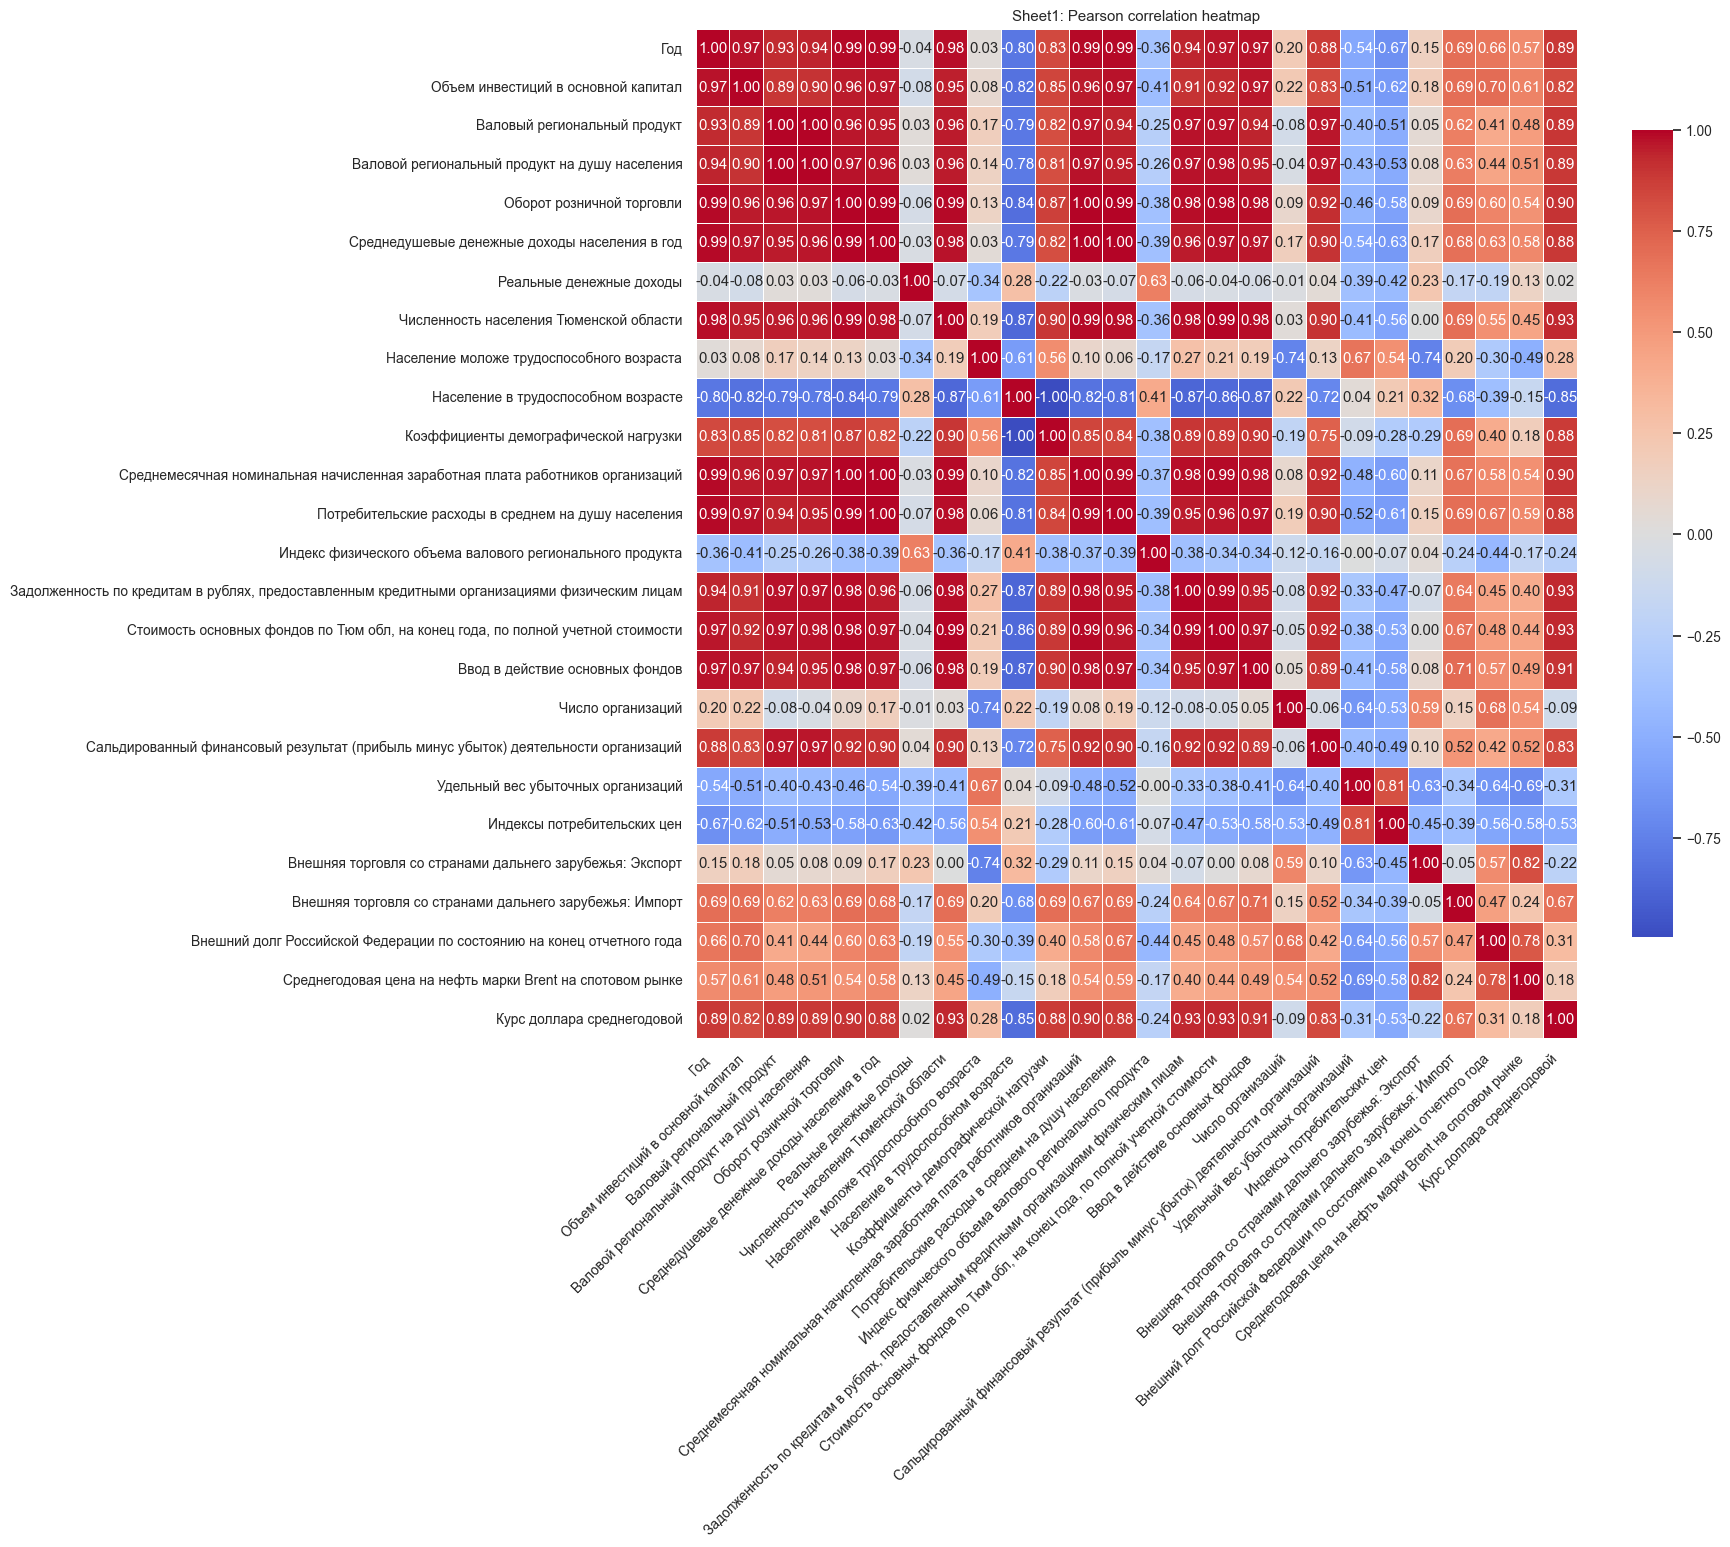


----------------------------------------------------------------------------------------------------
Корреляция (Spearman)


,Год,Объем инвестиций в основной капитал,Валовый региональный продукт,Валовой региональный продукт на душу населения,Оборот розничной торговли,Среднедушевые денежные доходы населения в год,Реальные денежные доходы,Численность населения Тюменской области,Население моложе трудоспособного возраста,Население в трудоспособном возрасте,Коэффициенты демографической нагрузки,Среднемесячная номинальная начисленная заработная плата работников организаций,Потребительские расходы в среднем на душу населения,Индекс физического объема валового регионального продукта,"Задолженность по кредитам в рублях, предоставленным кредитными организациями физическим лицам","Стоимость основных фондов по Тюм обл, на конец года, по полной учетной стоимости",Ввод в действие основных фондов,Число организаций,Сальдированный финансовый результат (прибыль минус убыток) деятельности организаций,Удельный вес убыточных организаций,Индексы потребительских цен,Внешняя торговля со странами дальнего зарубежья: Экспорт,Внешняя торговля со странами дальнего зарубежья: Импорт,Внешний долг Российской Федерации по состоянию на конец отчетного года,Среднегодовая цена на нефть марки Brent на спотовом рынке,Курс доллара среднегодовой
Год,1.000,0.966,0.997,0.995,1.000,0.999,-0.143,0.999,0.108,-0.744,0.762,1.000,0.997,-0.359,0.997,0.999,0.983,0.173,0.943,-0.409,-0.839,0.267,0.894,0.619,0.575,0.889
Объем инвестиций в основной капитал,0.966,1.000,0.971,0.973,0.966,0.966,-0.115,0.964,0.097,-0.734,0.757,0.966,0.966,-0.359,0.959,0.965,0.979,0.233,0.925,-0.409,-0.877,0.314,0.867,0.644,0.623,0.833
Валовый региональный продукт,0.997,0.971,1.000,0.999,0.997,0.998,-0.124,0.995,0.111,-0.740,0.760,0.997,0.998,-0.331,0.994,0.997,0.987,0.178,0.954,-0.416,-0.840,0.282,0.895,0.621,0.590,0.876
Валовой региональный продукт на душу населения,0.995,0.973,0.999,1.000,0.995,0.995,-0.124,0.992,0.111,-0.740,0.760,0.995,0.995,-0.313,0.990,0.994,0.987,0.184,0.955,-0.424,-0.841,0.284,0.899,0.621,0.595,0.871
Оборот розничной торговли,1.000,0.966,0.997,0.995,1.000,0.999,-0.143,0.999,0.108,-0.744,0.762,1.000,0.997,-0.359,0.997,0.999,0.983,0.173,0.943,-0.409,-0.839,0.267,0.894,0.619,0.575,0.889
Среднедушевые денежные доходы населения в год,0.999,0.966,0.998,0.995,0.999,1.000,-0.130,0.997,0.107,-0.742,0.761,0.999,0.998,-0.350,0.996,0.999,0.982,0.174,0.942,-0.411,-0.837,0.270,0.895,0.621,0.580,0.881
Реальные денежные доходы,-0.143,-0.115,-0.124,-0.124,-0.143,-0.130,1.000,-0.160,-0.263,0.405,-0.384,-0.143,-0.115,0.598,-0.144,-0.143,-0.117,-0.175,-0.091,-0.124,0.107,0.251,-0.255,-0.369,0.123,-0.203
Численность населения Тюменской области,0.999,0.964,0.995,0.992,0.999,0.997,-0.160,1.000,0.107,-0.744,0.762,0.999,0.995,-0.380,0.997,0.997,0.982,0.175,0.939,-0.407,-0.837,0.263,0.890,0.617,0.569,0.889
Население моложе трудоспособного возраста,0.108,0.097,0.111,0.111,0.108,0.107,-0.263,0.107,1.000,-0.699,0.677,0.108,0.106,-0.102,0.102,0.109,0.113,-0.676,0.082,0.618,-0.037,-0.712,0.203,-0.221,-0.466,0.277
Население в трудоспособном возрасте,-0.744,-0.734,-0.740,-0.740,-0.744,-0.742,0.405,-0.744,-0.699,1.000,-0.998,-0.744,-0.737,0.456,-0.739,-0.745,-0.738,0.217,-0.676,-0.089,0.610,0.252,-0.766,-0.386,-0.145,-0.747


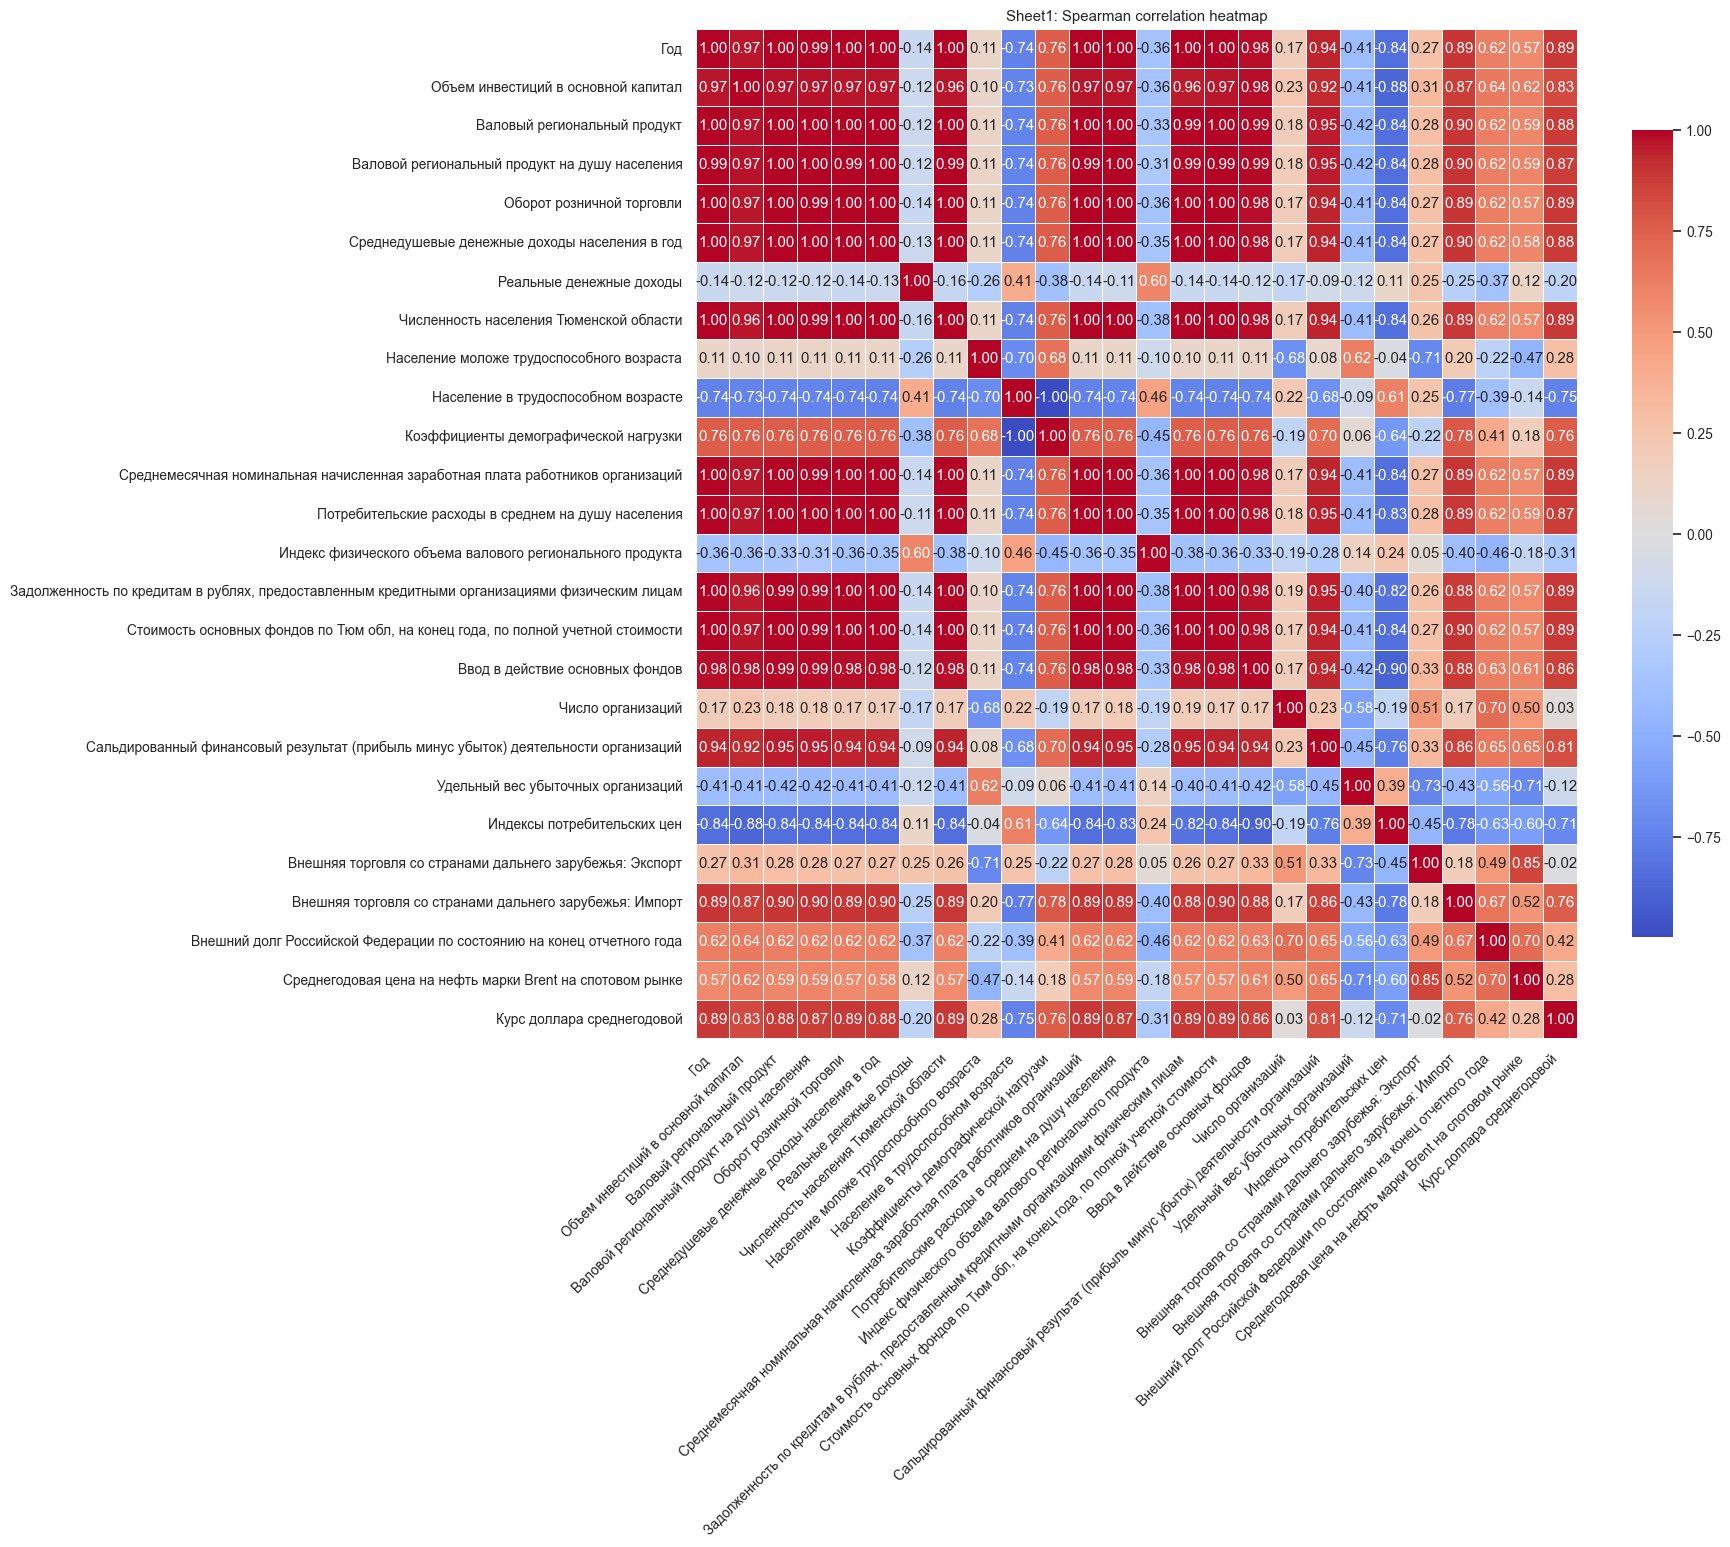


----------------------------------------------------------------------------------------------------
Корреляция (Kendall)


,Год,Объем инвестиций в основной капитал,Валовый региональный продукт,Валовой региональный продукт на душу населения,Оборот розничной торговли,Среднедушевые денежные доходы населения в год,Реальные денежные доходы,Численность населения Тюменской области,Население моложе трудоспособного возраста,Население в трудоспособном возрасте,Коэффициенты демографической нагрузки,Среднемесячная номинальная начисленная заработная плата работников организаций,Потребительские расходы в среднем на душу населения,Индекс физического объема валового регионального продукта,"Задолженность по кредитам в рублях, предоставленным кредитными организациями физическим лицам","Стоимость основных фондов по Тюм обл, на конец года, по полной учетной стоимости",Ввод в действие основных фондов,Число организаций,Сальдированный финансовый результат (прибыль минус убыток) деятельности организаций,Удельный вес убыточных организаций,Индексы потребительских цен,Внешняя торговля со странами дальнего зарубежья: Экспорт,Внешняя торговля со странами дальнего зарубежья: Импорт,Внешний долг Российской Федерации по состоянию на конец отчетного года,Среднегодовая цена на нефть марки Brent на спотовом рынке,Курс доллара среднегодовой
Год,1.000,0.895,0.982,0.969,1.000,0.994,-0.077,0.988,0.137,-0.559,0.569,1.000,0.975,-0.262,0.982,0.994,0.926,0.138,0.822,-0.238,-0.674,0.243,0.735,0.415,0.446,0.729
Объем инвестиций в основной капитал,0.895,1.000,0.914,0.926,0.895,0.902,-0.046,0.883,0.119,-0.534,0.551,0.895,0.895,-0.269,0.877,0.889,0.920,0.218,0.778,-0.244,-0.729,0.298,0.705,0.471,0.489,0.625
Валовый региональный продукт,0.982,0.914,1.000,0.988,0.982,0.988,-0.058,0.969,0.144,-0.546,0.563,0.982,0.982,-0.244,0.963,0.975,0.932,0.157,0.828,-0.256,-0.680,0.262,0.742,0.422,0.465,0.711
Валовой региональный продукт на душу населения,0.969,0.926,0.988,1.000,0.969,0.975,-0.058,0.957,0.144,-0.546,0.563,0.969,0.969,-0.231,0.951,0.963,0.932,0.169,0.828,-0.256,-0.692,0.274,0.742,0.422,0.477,0.698
Оборот розничной торговли,1.000,0.895,0.982,0.969,1.000,0.994,-0.077,0.988,0.137,-0.559,0.569,1.000,0.975,-0.262,0.982,0.994,0.926,0.138,0.822,-0.238,-0.674,0.243,0.735,0.415,0.446,0.729
Среднедушевые денежные доходы населения в год,0.994,0.902,0.988,0.975,0.994,1.000,-0.071,0.982,0.131,-0.552,0.563,0.994,0.982,-0.256,0.975,0.988,0.920,0.145,0.815,-0.244,-0.668,0.249,0.742,0.422,0.452,0.723
Реальные денежные доходы,-0.077,-0.046,-0.058,-0.058,-0.077,-0.071,1.000,-0.089,-0.206,0.231,-0.212,-0.077,-0.052,0.410,-0.083,-0.083,-0.028,-0.138,-0.046,-0.071,0.083,0.225,-0.145,-0.255,0.083,-0.151
Численность населения Тюменской области,0.988,0.883,0.969,0.957,0.988,0.982,-0.089,1.000,0.137,-0.559,0.569,0.988,0.963,-0.275,0.982,0.982,0.914,0.138,0.809,-0.225,-0.662,0.231,0.723,0.415,0.434,0.729
Население моложе трудоспособного возраста,0.137,0.119,0.144,0.144,0.137,0.131,-0.206,0.137,1.000,-0.570,0.555,0.137,0.125,-0.063,0.119,0.144,0.144,-0.481,0.081,0.495,-0.069,-0.506,0.162,-0.150,-0.337,0.281
Население в трудоспособном возрасте,-0.559,-0.534,-0.546,-0.546,-0.559,-0.552,0.231,-0.559,-0.570,1.000,-0.985,-0.559,-0.534,0.313,-0.540,-0.565,-0.540,0.133,-0.460,-0.115,0.423,0.133,-0.540,-0.219,-0.071,-0.552


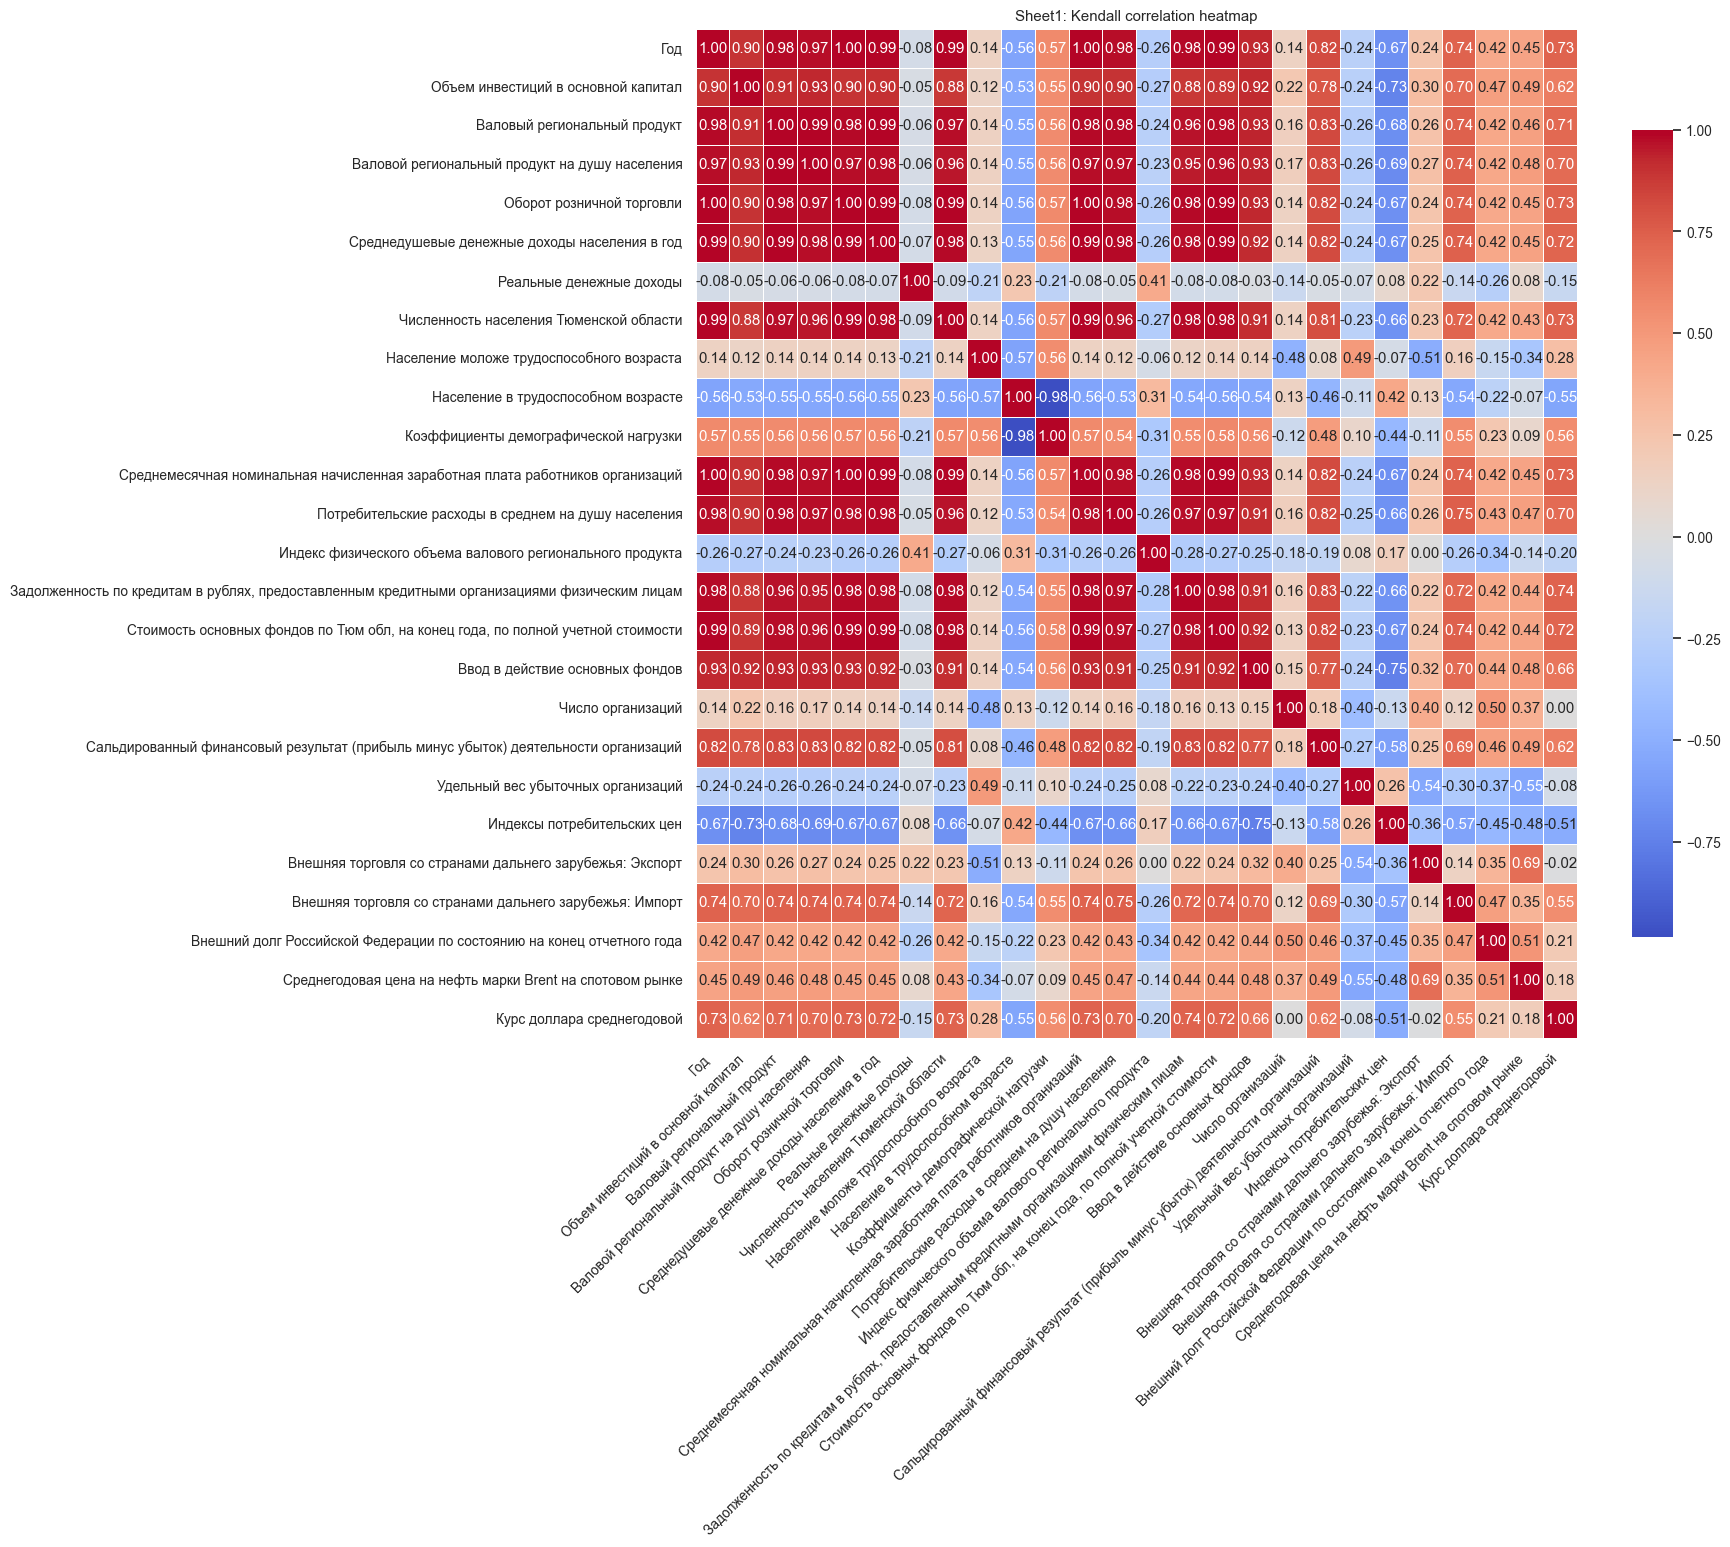

In [8]:
correlation_methods = ['pearson', 'spearman', 'kendall']
correlation_results = {}

for sheet, df in prepared_sheets.items():
    numeric_df = df.select_dtypes(include=['number']).copy().dropna(axis=1, how='all')

    print('=' * 100)
    print(f'Корреляционный анализ для листа: {sheet}')
    print(f'Числовых столбцов для анализа: {numeric_df.shape[1]}')

    if numeric_df.shape[1] < 2:
        print('Недостаточно числовых признаков для расчёта корреляции.')
        continue

    correlation_results[sheet] = {}

    for method in correlation_methods:
        corr = numeric_df.corr(method=method)
        correlation_results[sheet][method] = corr

        print('\n' + '-' * 100)
        print(f'Корреляция ({method.title()})')
        display(corr.round(3))

        plt.figure(figsize=(max(8, numeric_df.shape[1] * 0.7), max(6, numeric_df.shape[1] * 0.6)))
        sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5, cbar_kws={'shrink': 0.8})
        plt.title(f'{sheet}: {method.title()} correlation heatmap')
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()


## Целевой признак и отобранные факторы

Целевой признак:
- `Объем инвестиций в основной капитал`

Для первого табличного ML-пайплайна оставляем:
- сильные положительные факторы;
- только `Валовой региональный продукт на душу населения`;
- три самых заметных отрицательных корреляции.

`Год` в признаки не включаем, чтобы модель не училась только на времени.


In [9]:
TARGET_COLUMN = 'Объем инвестиций в основной капитал'
YEAR_COLUMN = 'Год'

SELECTED_FEATURES = [
    'Потребительские расходы в среднем на душу населения',
    'Ввод в действие основных фондов',
    'Среднедушевые денежные доходы населения в год',
    'Оборот розничной торговли',
    'Среднемесячная номинальная начисленная заработная плата работников организаций',
    'Численность населения Тюменской области',
    'Стоимость основных фондов по Тюм обл, на конец года, по полной учетной стоимости',
    'Задолженность по кредитам в рублях, предоставленным кредитными организациями физическим лицам',
    'Валовой региональный продукт на душу населения',
    'Население в трудоспособном возрасте',
    'Индексы потребительских цен',
    'Удельный вес убыточных организаций',
]

LAG_FEATURES = [
    TARGET_COLUMN,
    'Ввод в действие основных фондов',
    'Валовой региональный продукт на душу населения',
    'Среднемесячная номинальная начисленная заработная плата работников организаций',
    'Потребительские расходы в среднем на душу населения',
]

SELECTED_FEATURES

['Потребительские расходы в среднем на душу населения',
 'Ввод в действие основных фондов',
 'Среднедушевые денежные доходы населения в год',
 'Оборот розничной торговли',
 'Среднемесячная номинальная начисленная заработная плата работников организаций',
 'Численность населения Тюменской области',
 'Стоимость основных фондов по Тюм обл, на конец года, по полной учетной стоимости',
 'Задолженность по кредитам в рублях, предоставленным кредитными организациями физическим лицам',
 'Валовой региональный продукт на душу населения',
 'Население в трудоспособном возрасте',
 'Индексы потребительских цен',
 'Удельный вес убыточных организаций']

In [10]:
df = prepared_sheets[sheet_names[0]].copy()
required_columns = [YEAR_COLUMN, TARGET_COLUMN, *SELECTED_FEATURES]
missing_columns = [col for col in required_columns if col not in df.columns]

if missing_columns:
    raise ValueError(f'В датасете отсутствуют нужные столбцы: {missing_columns}')

model_df = df[required_columns].copy().sort_values(YEAR_COLUMN).reset_index(drop=True)
model_df

,Год,Объем инвестиций в основной капитал,Потребительские расходы в среднем на душу населения,Ввод в действие основных фондов,Среднедушевые денежные доходы населения в год,Оборот розничной торговли,Среднемесячная номинальная начисленная заработная плата работников организаций,Численность населения Тюменской области,"Стоимость основных фондов по Тюм обл, на конец года, по полной учетной стоимости","Задолженность по кредитам в рублях, предоставленным кредитными организациями физическим лицам",Валовой региональный продукт на душу населения,Население в трудоспособном возрасте,Индексы потребительских цен,Удельный вес убыточных организаций
0,1998,4738.000,1270.2,47050,2129.00000,1042799.4,2792.9,3212536,903930,1396.89,58587.7,63.9,164.5,56.7
1,1999,5995.200,1879.9,51746,3266.00000,1797390.0,4054.8,3226093,782654,1462.86,98130.1,64.7,136.3,44.3
2,2000,10434.300,2144.0,103378,4935.00000,2352274.3,6706.8,3218356,1350459,1570.60,176917.9,66.3,120.8,39.4
3,2001,13849.500,2954.0,174764,7109.00000,3070014.0,9980.0,3234252,2575384,1571.00,232236.3,67.0,119.9,34.5
4,2002,17209.900,3870.0,256363,8559.00000,3765363.6,12083.3,3264841,3416427,3952.10,275622.5,67.8,115.5,43.2
5,2003,21080.000,5109.0,269870,10569.00000,4529632.9,14584.1,3269862,3780191,6991.60,341146.7,68.6,110.7,41.9
6,2004,36650.800,6471.0,276232,12242.00000,5642497.7,16956.5,3290082,4125299,15171.20,467803.8,69.1,109.8,36.7
7,2005,56322.800,8371.0,353223,14983.00000,7041509.1,19838.0,3307481,5405244,31022.00,673208.3,69.3,111.8,34.7
8,2006,87578.900,11127.0,386685,18813.00000,8711919.9,23728.7,3323303,6462995,52123.00,773076.2,69.3,111.5,28.1
9,2007,106571.900,14246.0,545951,22795.00000,10868976.4,28565.0,3345127,7581168,92274.50,831305.3,68.9,108.9,22.6


## Корреляции только по целевому признаку

In [11]:
target_corr_report = pd.DataFrame({
    'feature': SELECTED_FEATURES,
    'pearson': [model_df[[TARGET_COLUMN, col]].corr(method='pearson').iloc[0, 1] for col in SELECTED_FEATURES],
    'spearman': [model_df[[TARGET_COLUMN, col]].corr(method='spearman').iloc[0, 1] for col in SELECTED_FEATURES],
    'kendall': [model_df[[TARGET_COLUMN, col]].corr(method='kendall').iloc[0, 1] for col in SELECTED_FEATURES],
})
target_corr_report['abs_pearson'] = target_corr_report['pearson'].abs()
target_corr_report.sort_values('abs_pearson', ascending=False)

,feature,pearson,spearman,kendall,abs_pearson
0,Потребительские расходы в среднем на душу насе...,0.974209,0.965812,0.895385,0.974209
1,Ввод в действие основных фондов,0.966359,0.978803,0.920000,0.966359
2,Среднедушевые денежные доходы населения в год,0.966155,0.966496,0.901538,0.966155
3,Оборот розничной торговли,0.960654,0.965812,0.895385,0.960654
4,Среднемесячная номинальная начисленная заработ...,0.957380,0.965812,0.895385,0.957380
5,Численность населения Тюменской области,0.945439,0.963761,0.883077,0.945439
6,"Стоимость основных фондов по Тюм обл, на конец...",0.922474,0.965128,0.889231,0.922474
7,"Задолженность по кредитам в рублях, предоставл...",0.905636,0.958974,0.876923,0.905636
8,Валовой региональный продукт на душу населения,0.903581,0.972650,0.926154,0.903581
9,Население в трудоспособном возрасте,-0.819537,-0.733926,-0.533953,0.819537


## Предобработка для первого ML-пайплайна

In [12]:
train_df = model_df.iloc[:-2].copy()
validation_df = model_df.iloc[-2:-1].copy()
test_df = model_df.iloc[-1:].copy()

print('Train years:', train_df[YEAR_COLUMN].tolist())
print('Validation year:', validation_df[YEAR_COLUMN].tolist())
print('Test year:', test_df[YEAR_COLUMN].tolist())


Train years: [1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]
Validation year: [2022]
Test year: [2023]


In [13]:
X_train = train_df[SELECTED_FEATURES]
y_train = train_df[TARGET_COLUMN]

X_validation = validation_df[SELECTED_FEATURES]
y_validation = validation_df[TARGET_COLUMN]

X_test = test_df[SELECTED_FEATURES]
y_test = test_df[TARGET_COLUMN]

print('Shapes:')
print('X_train:', X_train.shape, 'y_train:', y_train.shape)
print('X_validation:', X_validation.shape, 'y_validation:', y_validation.shape)
print('X_test:', X_test.shape, 'y_test:', y_test.shape)


Shapes:
X_train: (24, 12) y_train: (24,)
X_validation: (1, 12) y_validation: (1,)
X_test: (1, 12) y_test: (1,)


In [14]:
scaler_preview_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

X_train_scaled_preview = pd.DataFrame(
    scaler_preview_pipeline.fit_transform(X_train),
    columns=SELECTED_FEATURES,
    index=train_df.index,
)

X_train_scaled_preview.head()

,Потребительские расходы в среднем на душу населения,Ввод в действие основных фондов,Среднедушевые денежные доходы населения в год,Оборот розничной торговли,Среднемесячная номинальная начисленная заработная плата работников организаций,Численность населения Тюменской области,"Стоимость основных фондов по Тюм обл, на конец года, по полной учетной стоимости","Задолженность по кредитам в рублях, предоставленным кредитными организациями физическим лицам",Валовой региональный продукт на душу населения,Население в трудоспособном возрасте,Индексы потребительских цен,Удельный вес убыточных организаций
0,-1.421339,-1.209649,-1.564911,-1.340579,-1.460642,-1.241467,-1.155659,-0.977149,-1.349266,-0.231931,3.990666,3.281034
1,-1.369414,-1.203993,-1.494174,-1.277264,-1.409100,-1.168482,-1.166200,-0.976921,-1.299298,-0.012568,1.826670,1.482147
2,-1.346922,-1.141807,-1.390338,-1.230707,-1.300780,-1.210135,-1.116847,-0.976549,-1.199736,0.426159,0.637240,0.771297
3,-1.277939,-1.055828,-1.255085,-1.170484,-1.167088,-1.124558,-1.010377,-0.976548,-1.129833,0.618102,0.568177,0.060446
4,-1.199928,-0.957549,-1.164874,-1.112141,-1.081179,-0.959879,-0.937275,-0.968329,-1.075007,0.837466,0.230532,1.322568


## ML-модели

Проверяем линейные модели, деревья, ансамбли, `SVR`, `KNN` и `MLPRegressor`.
Для разового `validation/test` этого достаточно, но ниже будет более полезная временная проверка через `walk-forward`.


In [15]:
def build_scaled_model(model):
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', model),
    ])


def build_tree_model(model):
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', model),
    ])


base_models = {
    'LinearRegression': build_scaled_model(LinearRegression()),
    'Ridge': build_scaled_model(Ridge(alpha=1.0)),
    'Lasso': build_scaled_model(Lasso(alpha=0.01, max_iter=10000, random_state=42)),
    'ElasticNet': build_scaled_model(ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000, random_state=42)),
    'SVR_rbf': build_scaled_model(SVR(kernel='rbf', C=10.0, epsilon=0.1)),
    'KNN': build_scaled_model(KNeighborsRegressor(n_neighbors=3, weights='distance')),
    'DecisionTree': build_tree_model(DecisionTreeRegressor(max_depth=4, random_state=42)),
    'RandomForest': build_tree_model(RandomForestRegressor(n_estimators=300, max_depth=5, random_state=42)),
    'ExtraTrees': build_tree_model(ExtraTreesRegressor(n_estimators=300, max_depth=5, random_state=42)),
    'GradientBoosting': build_tree_model(GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42)),
    'AdaBoost': build_tree_model(AdaBoostRegressor(n_estimators=200, learning_rate=0.05, random_state=42)),
    'MLPRegressor': build_scaled_model(MLPRegressor(hidden_layer_sizes=(64, 32), activation='relu', solver='adam', alpha=0.0001, learning_rate_init=0.001, max_iter=5000, random_state=42)),
}


def wrap_for_target(model, use_log_target=False):
    if use_log_target:
        transformer = FunctionTransformer(np.log1p, np.expm1, validate=True)
    else:
        transformer = StandardScaler()
    return TransformedTargetRegressor(regressor=clone(model), transformer=transformer)


In [16]:
evaluation_rows = []
trained_models = {}

for model_name, model in base_models.items():
    wrapped_model = wrap_for_target(model, use_log_target=False)
    wrapped_model.fit(X_train, y_train)
    trained_models[model_name] = wrapped_model

    val_pred = wrapped_model.predict(X_validation)
    test_pred = wrapped_model.predict(X_test)

    evaluation_rows.append({
        'model': model_name,
        'validation_year': int(validation_df[YEAR_COLUMN].iloc[0]),
        'validation_actual': float(y_validation.iloc[0]),
        'validation_pred': float(val_pred[0]),
        'validation_mae': float(mean_absolute_error(y_validation, val_pred)),
        'validation_rmse': float(np.sqrt(mean_squared_error(y_validation, val_pred))),
        'validation_mape': float(mean_absolute_percentage_error(y_validation, val_pred)),
        'test_year': int(test_df[YEAR_COLUMN].iloc[0]),
        'test_actual': float(y_test.iloc[0]),
        'test_pred': float(test_pred[0]),
        'test_mae': float(mean_absolute_error(y_test, test_pred)),
        'test_rmse': float(np.sqrt(mean_squared_error(y_test, test_pred))),
        'test_mape': float(mean_absolute_percentage_error(y_test, test_pred)),
    })

evaluation_df = pd.DataFrame(evaluation_rows).sort_values(['test_mae', 'validation_mae']).reset_index(drop=True)
evaluation_df

,model,validation_year,validation_actual,validation_pred,validation_mae,validation_rmse,validation_mape,test_year,test_actual,test_pred,test_mae,test_rmse,test_mape
0,LinearRegression,2022,353203.5,296462.972569,56740.527431,56740.527431,0.160645,2023,356719.9,353405.625588,3314.274412,3314.274412,0.009291
1,Ridge,2022,353203.5,308314.367973,44889.132027,44889.132027,0.127091,2023,356719.9,362379.149689,5659.249689,5659.249689,0.015865
2,ElasticNet,2022,353203.5,290593.528447,62609.971553,62609.971553,0.177263,2023,356719.9,364987.074575,8267.174575,8267.174575,0.023176
3,Lasso,2022,353203.5,302341.425333,50862.074667,50862.074667,0.144002,2023,356719.9,383583.843583,26863.943583,26863.943583,0.075308
4,KNN,2022,353203.5,267038.745463,86164.754537,86164.754537,0.243952,2023,356719.9,272656.726939,84063.173061,84063.173061,0.235656
5,MLPRegressor,2022,353203.5,235180.199898,118023.300102,118023.300102,0.334151,2023,356719.9,261822.979611,94896.920389,94896.920389,0.266026
6,RandomForest,2022,353203.5,278134.234344,75069.265656,75069.265656,0.212538,2023,356719.9,258257.295477,98462.604523,98462.604523,0.276022
7,ExtraTrees,2022,353203.5,241791.095398,111412.404602,111412.404602,0.315434,2023,356719.9,248026.313317,108693.586683,108693.586683,0.304703
8,GradientBoosting,2022,353203.5,271606.594953,81596.905047,81596.905047,0.231020,2023,356719.9,240566.665230,116153.234770,116153.234770,0.325615
9,AdaBoost,2022,353203.5,301333.992000,51869.508000,51869.508000,0.146854,2023,356719.9,238470.250000,118249.650000,118249.650000,0.331492


## Лучшая модель на простом разбиении

In [17]:
best_model_name = evaluation_df.iloc[0]['model']
best_model = trained_models[best_model_name]

print('Лучшая модель по простому разбиению:', best_model_name)
display(evaluation_df.head(5))

Лучшая модель по простому разбиению: LinearRegression


,model,validation_year,validation_actual,validation_pred,validation_mae,validation_rmse,validation_mape,test_year,test_actual,test_pred,test_mae,test_rmse,test_mape
0,LinearRegression,2022,353203.5,296462.972569,56740.527431,56740.527431,0.160645,2023,356719.9,353405.625588,3314.274412,3314.274412,0.009291
1,Ridge,2022,353203.5,308314.367973,44889.132027,44889.132027,0.127091,2023,356719.9,362379.149689,5659.249689,5659.249689,0.015865
2,ElasticNet,2022,353203.5,290593.528447,62609.971553,62609.971553,0.177263,2023,356719.9,364987.074575,8267.174575,8267.174575,0.023176
3,Lasso,2022,353203.5,302341.425333,50862.074667,50862.074667,0.144002,2023,356719.9,383583.843583,26863.943583,26863.943583,0.075308
4,KNN,2022,353203.5,267038.745463,86164.754537,86164.754537,0.243952,2023,356719.9,272656.726939,84063.173061,84063.173061,0.235656


In [18]:
base_regressor = best_model.regressor_
final_model = base_regressor.named_steps.get('model') if hasattr(base_regressor, 'named_steps') else base_regressor

if hasattr(final_model, 'coef_'):
    feature_importance_df = pd.DataFrame({
        'feature': SELECTED_FEATURES,
        'importance': final_model.coef_,
        'abs_importance': np.abs(final_model.coef_),
    }).sort_values('abs_importance', ascending=False)
    display(feature_importance_df)
elif hasattr(final_model, 'feature_importances_'):
    feature_importance_df = pd.DataFrame({
        'feature': SELECTED_FEATURES,
        'importance': final_model.feature_importances_,
    }).sort_values('importance', ascending=False)
    display(feature_importance_df)
else:
    print('У выбранной модели нет встроенной оценки важности признаков.')


,feature,importance,abs_importance
4,Среднемесячная номинальная начисленная заработ...,3.228277,3.228277
3,Оборот розничной торговли,-1.971418,1.971418
0,Потребительские расходы в среднем на душу насе...,1.680212,1.680212
2,Среднедушевые денежные доходы населения в год,-1.058343,1.058343
6,"Стоимость основных фондов по Тюм обл, на конец...",-0.970159,0.970159
9,Население в трудоспособном возрасте,-0.520199,0.520199
7,"Задолженность по кредитам в рублях, предоставл...",-0.500961,0.500961
5,Численность населения Тюменской области,-0.303944,0.303944
1,Ввод в действие основных фондов,0.262541,0.262541
8,Валовой региональный продукт на душу населения,0.125024,0.125024


## Улучшение: лаги и walk-forward validation

Чтобы уменьшить ошибку на временном ряде, проверяем три постановки:
- `baseline`: только текущие признаки;
- `log_target`: те же признаки, но прогнозируем логарифм целевой переменной;
- `lagged`: добавляем лаги по ключевым признакам и по самой целевой переменной.


In [19]:
def add_lag_features(df: pd.DataFrame, columns: list[str], lags: tuple[int, ...] = (1, 2)) -> pd.DataFrame:
    lagged_df = df.copy()
    for col in columns:
        for lag in lags:
            lagged_df[f'{col}_lag_{lag}'] = lagged_df[col].shift(lag)
    return lagged_df


lagged_model_df = add_lag_features(model_df, LAG_FEATURES, lags=(1, 2))

LAGGED_FEATURES = SELECTED_FEATURES + [
    col for col in lagged_model_df.columns
    if any(col == f'{base_col}_lag_{lag}' for base_col in LAG_FEATURES for lag in (1, 2))
]

lagged_model_df[[YEAR_COLUMN, TARGET_COLUMN, *LAGGED_FEATURES]].head(6)

,Год,Объем инвестиций в основной капитал,Потребительские расходы в среднем на душу населения,Ввод в действие основных фондов,Среднедушевые денежные доходы населения в год,Оборот розничной торговли,Среднемесячная номинальная начисленная заработная плата работников организаций,Численность населения Тюменской области,"Стоимость основных фондов по Тюм обл, на конец года, по полной учетной стоимости","Задолженность по кредитам в рублях, предоставленным кредитными организациями физическим лицам",Валовой региональный продукт на душу населения,Население в трудоспособном возрасте,Индексы потребительских цен,Удельный вес убыточных организаций,Объем инвестиций в основной капитал_lag_1,Объем инвестиций в основной капитал_lag_2,Ввод в действие основных фондов_lag_1,Ввод в действие основных фондов_lag_2,Валовой региональный продукт на душу населения_lag_1,Валовой региональный продукт на душу населения_lag_2,Среднемесячная номинальная начисленная заработная плата работников организаций_lag_1,Среднемесячная номинальная начисленная заработная плата работников организаций_lag_2,Потребительские расходы в среднем на душу населения_lag_1,Потребительские расходы в среднем на душу населения_lag_2
0,1998,4738.0,1270.2,47050,2129.0,1042799.4,2792.9,3212536,903930,1396.89,58587.7,63.9,164.5,56.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1999,5995.2,1879.9,51746,3266.0,1797390.0,4054.8,3226093,782654,1462.86,98130.1,64.7,136.3,44.3,4738.0,NaN,47050.0,NaN,58587.7,NaN,2792.9,NaN,1270.2,NaN
2,2000,10434.3,2144.0,103378,4935.0,2352274.3,6706.8,3218356,1350459,1570.60,176917.9,66.3,120.8,39.4,5995.2,4738.0,51746.0,47050.0,98130.1,58587.7,4054.8,2792.9,1879.9,1270.2
3,2001,13849.5,2954.0,174764,7109.0,3070014.0,9980.0,3234252,2575384,1571.00,232236.3,67.0,119.9,34.5,10434.3,5995.2,103378.0,51746.0,176917.9,98130.1,6706.8,4054.8,2144.0,1879.9
4,2002,17209.9,3870.0,256363,8559.0,3765363.6,12083.3,3264841,3416427,3952.10,275622.5,67.8,115.5,43.2,13849.5,10434.3,174764.0,103378.0,232236.3,176917.9,9980.0,6706.8,2954.0,2144.0
5,2003,21080.0,5109.0,269870,10569.0,4529632.9,14584.1,3269862,3780191,6991.60,341146.7,68.6,110.7,41.9,17209.9,13849.5,256363.0,174764.0,275622.5,232236.3,12083.3,9980.0,3870.0,2954.0


In [20]:
def evaluate_predictions(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    return {
        'mae': float(mean_absolute_error(y_true, y_pred)),
        'rmse': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'mape': float(mean_absolute_percentage_error(y_true, y_pred)),
    }


def walk_forward_validate(data: pd.DataFrame, feature_columns: list[str], model_dict: dict, target_column: str, year_column: str, min_train_size: int = 12, use_log_target: bool = False) -> tuple[pd.DataFrame, dict]:
    valid_data = data[[year_column, target_column, *feature_columns]].dropna().reset_index(drop=True)
    rows = []
    predictions = {}

    for model_name, model in model_dict.items():
        yearly_predictions = []
        for split_idx in range(min_train_size, len(valid_data)):
            train_part = valid_data.iloc[:split_idx]
            test_part = valid_data.iloc[split_idx:split_idx + 1]

            X_tr = train_part[feature_columns]
            y_tr = train_part[target_column]
            X_te = test_part[feature_columns]
            y_te = test_part[target_column]

            fitted_model = wrap_for_target(model, use_log_target=use_log_target)
            fitted_model.fit(X_tr, y_tr)
            pred = fitted_model.predict(X_te)

            rows.append({
                'model': model_name,
                'predicted_year': int(test_part[year_column].iloc[0]),
                'train_end_year': int(train_part[year_column].iloc[-1]),
                'actual': float(y_te.iloc[0]),
                'predicted': float(pred[0]),
                'absolute_error': float(abs(y_te.iloc[0] - pred[0])),
                'absolute_percentage_error': float(abs(y_te.iloc[0] - pred[0]) / y_te.iloc[0]),
            })
            yearly_predictions.append((float(y_te.iloc[0]), float(pred[0])))

        predictions[model_name] = yearly_predictions

    details_df = pd.DataFrame(rows)

    summary_rows = []
    for model_name, yearly_predictions in predictions.items():
        y_true = np.array([actual for actual, _ in yearly_predictions])
        y_pred = np.array([pred for _, pred in yearly_predictions])
        metrics = evaluate_predictions(y_true, y_pred)
        summary_rows.append({
            'model': model_name,
            'folds': len(yearly_predictions),
            'walk_forward_mae': metrics['mae'],
            'walk_forward_rmse': metrics['rmse'],
            'walk_forward_mape': metrics['mape'],
        })

    summary_df = pd.DataFrame(summary_rows).sort_values(['walk_forward_mape', 'walk_forward_mae']).reset_index(drop=True)
    return summary_df, details_df


In [21]:
baseline_walk_summary, baseline_walk_details = walk_forward_validate(
    data=model_df,
    feature_columns=SELECTED_FEATURES,
    model_dict=base_models,
    target_column=TARGET_COLUMN,
    year_column=YEAR_COLUMN,
    min_train_size=12,
    use_log_target=False,
)

log_target_walk_summary, log_target_walk_details = walk_forward_validate(
    data=model_df,
    feature_columns=SELECTED_FEATURES,
    model_dict=base_models,
    target_column=TARGET_COLUMN,
    year_column=YEAR_COLUMN,
    min_train_size=12,
    use_log_target=True,
)

lagged_walk_summary, lagged_walk_details = walk_forward_validate(
    data=lagged_model_df,
    feature_columns=LAGGED_FEATURES,
    model_dict=base_models,
    target_column=TARGET_COLUMN,
    year_column=YEAR_COLUMN,
    min_train_size=12,
    use_log_target=True,
)

baseline_walk_summary.head()

,model,folds,walk_forward_mae,walk_forward_rmse,walk_forward_mape
0,Lasso,14,31503.250456,40876.196460,0.119203
1,Ridge,14,32308.188004,44308.832134,0.123145
2,MLPRegressor,14,35156.649442,44749.057739,0.124400
3,ElasticNet,14,33824.694974,44945.876214,0.127386
4,AdaBoost,14,39831.294082,49865.987841,0.144272


In [22]:
comparison_df = pd.concat([
    baseline_walk_summary.assign(configuration='baseline'),
    log_target_walk_summary.assign(configuration='log_target'),
    lagged_walk_summary.assign(configuration='lagged_log_target'),
], ignore_index=True)

comparison_df = comparison_df.sort_values(['walk_forward_mape', 'walk_forward_mae']).reset_index(drop=True)
comparison_df

,model,folds,walk_forward_mae,walk_forward_rmse,walk_forward_mape,configuration
0,Lasso,14,3.150325e+04,4.087620e+04,0.119203,baseline
1,Ridge,14,3.230819e+04,4.430883e+04,0.123145,baseline
2,MLPRegressor,14,3.515665e+04,4.474906e+04,0.124400,baseline
3,ElasticNet,14,3.382469e+04,4.494588e+04,0.127386,baseline
4,GradientBoosting,14,3.923849e+04,4.848873e+04,0.141446,log_target
5,DecisionTree,12,4.359567e+04,5.997142e+04,0.141515,lagged_log_target
6,AdaBoost,14,3.983129e+04,4.986599e+04,0.144272,baseline
7,GradientBoosting,12,4.438005e+04,5.121372e+04,0.152749,lagged_log_target
8,ExtraTrees,14,4.222922e+04,5.008782e+04,0.153291,baseline
9,RandomForest,14,4.228976e+04,5.045313e+04,0.154691,baseline


In [23]:
best_walk_row = comparison_df.iloc[0]
best_walk_model_name = best_walk_row['model']
best_configuration = best_walk_row['configuration']

print('Лучшая комбинация по walk-forward:')
display(best_walk_row.to_frame().T)


Лучшая комбинация по walk-forward:


,model,folds,walk_forward_mae,walk_forward_rmse,walk_forward_mape,configuration
0,Lasso,14,31503.250456,40876.19646,0.119203,baseline


In [24]:
details_map = {
    'baseline': baseline_walk_details,
    'log_target': log_target_walk_details,
    'lagged_log_target': lagged_walk_details,
}

best_walk_details = details_map[best_configuration]
best_walk_details = best_walk_details[best_walk_details['model'] == best_walk_model_name].reset_index(drop=True)
best_walk_details.head(10)

,model,predicted_year,train_end_year,actual,predicted,absolute_error,absolute_percentage_error
0,Lasso,2010,2009,154825.600,141804.513102,13021.086898,0.084102
1,Lasso,2011,2010,184240.100,178642.622955,5597.477045,0.030381
2,Lasso,2012,2011,204858.200,214794.076526,9935.876526,0.048501
3,Lasso,2013,2012,244667.800,243013.400671,1654.399329,0.006762
4,Lasso,2014,2013,248190.700,264162.890423,15972.190423,0.064355
5,Lasso,2015,2014,217380.900,268166.504649,50785.604649,0.233625
6,Lasso,2016,2015,239758.713,275303.122164,35544.409164,0.148251
7,Lasso,2017,2016,301333.992,279662.794169,21671.197831,0.071918
8,Lasso,2018,2017,353633.284,320999.609874,32633.674126,0.092281
9,Lasso,2019,2018,302730.582,344341.086719,41610.504719,0.137451


## График ошибок лучшей конфигурации

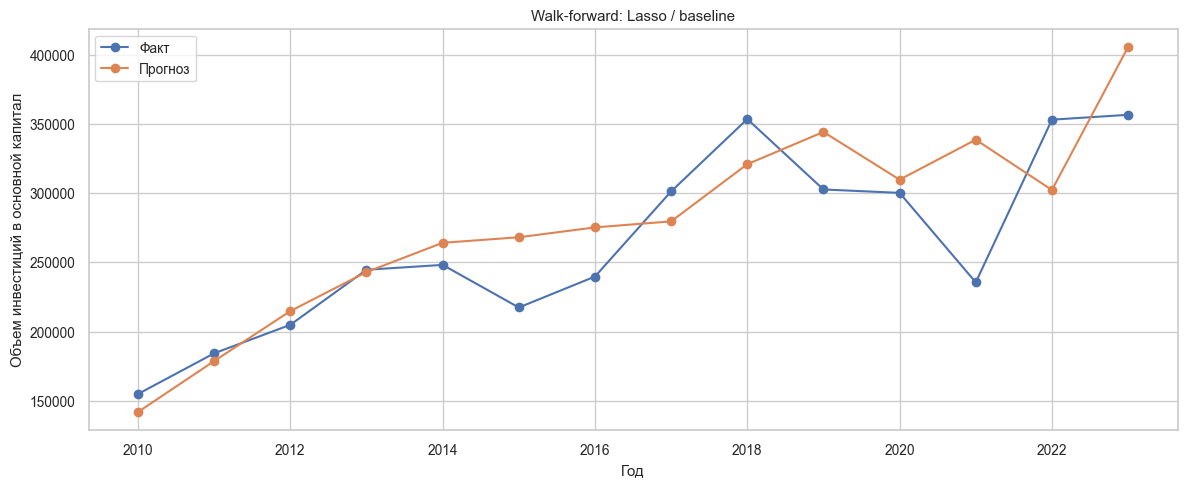

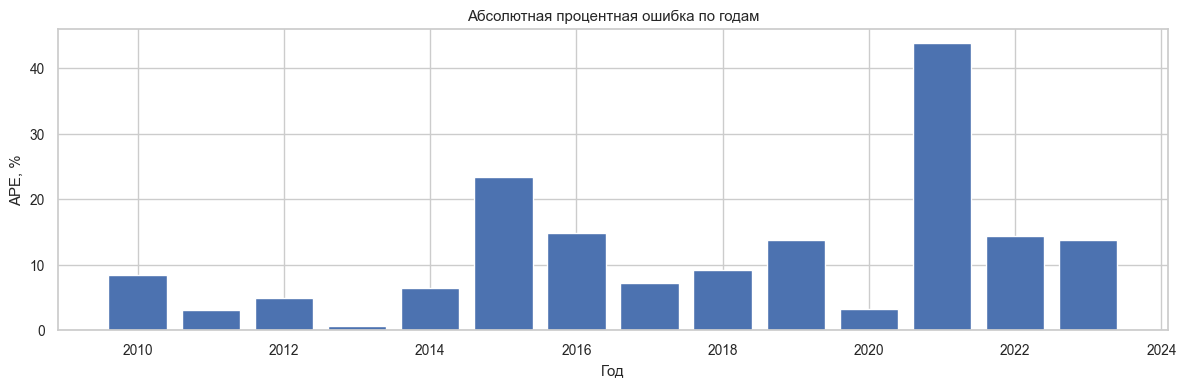

In [25]:
plt.figure(figsize=(12, 5))
plt.plot(best_walk_details['predicted_year'], best_walk_details['actual'], marker='o', label='Факт')
plt.plot(best_walk_details['predicted_year'], best_walk_details['predicted'], marker='o', label='Прогноз')
plt.title(f'Walk-forward: {best_walk_model_name} / {best_configuration}')
plt.xlabel('Год')
plt.ylabel(TARGET_COLUMN)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plt.bar(best_walk_details['predicted_year'], best_walk_details['absolute_percentage_error'] * 100)
plt.title('Абсолютная процентная ошибка по годам')
plt.xlabel('Год')
plt.ylabel('APE, %')
plt.tight_layout()
plt.show()


## Подготовка прогноза следующего года

Сценарий использования:
- есть фактические признаки до `2024` года;
- строка за `2024` подаётся на вход;
- на выходе получаем прогноз `Объема инвестиций в основной капитал` на `2025` год.

Ниже модель для продакшн-прогноза выбирается по лучшему результату `walk-forward validation`.


In [26]:
if best_configuration == 'baseline':
    production_df = model_df.copy()
    production_features = SELECTED_FEATURES
    production_use_log = False
elif best_configuration == 'log_target':
    production_df = model_df.copy()
    production_features = SELECTED_FEATURES
    production_use_log = True
else:
    production_df = lagged_model_df.copy().dropna().reset_index(drop=True)
    production_features = LAGGED_FEATURES
    production_use_log = True

production_model = wrap_for_target(base_models[best_walk_model_name], use_log_target=production_use_log)
production_model.fit(production_df[production_features], production_df[TARGET_COLUMN])

latest_actual_row = production_df.iloc[[-1]].copy()
latest_year = int(latest_actual_row[YEAR_COLUMN].iloc[0])
forecast_year = latest_year + 1

next_year_features = latest_actual_row[production_features]
next_year_prediction = float(production_model.predict(next_year_features)[0])

pd.DataFrame({
    'selected_configuration': [best_configuration],
    'selected_model': [best_walk_model_name],
    'base_year_with_actual_features': [latest_year],
    'forecast_year': [forecast_year],
    'predicted_investment_volume': [next_year_prediction],
})

,selected_configuration,selected_model,base_year_with_actual_features,forecast_year,predicted_investment_volume
0,baseline,Lasso,2023,2024,381600.512411


## Как использовать дальше

Что теперь можно делать в этом ноутбуке:
- сравнить простые ML-модели на фиксированном наборе признаков;
- проверить, снижают ли лаги ошибку;
- посмотреть, помогает ли `log(target)`;
- выбрать лучшую конфигурацию по `walk-forward`, а не по одному году.

Следующий этап для `LSTM`:
- подготовить последовательности по годам;
- выбрать окно истории;
- добавить лаги уже в формате временного ряда;
- сравнить `LSTM` против лучшей табличной ML-модели.
